# Velocity Comparison (MultiVelo)
After computing the RNA velocities per cell using also the ATAC data, the cells are split into two cohorts, based on accessibility of different transcription factor motifs. The velocities of cells that are close in the RNA space, but far apart for this one transcription factor are compared.

In [28]:
import scanpy as sc
import numpy as np 
import matplotlib.pyplot as plt
import multivelo as mv
import pandas as pd
import scvelo as scv
from pathlib import Path

In [2]:
python_data_dir = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data"
mv_data = sc.read_h5ad(rf"{python_data_dir}\multivelo_results.h5ad")
adata_atac = sc.read_h5ad(fr"{python_data_dir}\all_atac_aggregated_peaks.h5ad")

In [3]:
adata_atac = adata_atac[mv_data.obs_names, mv_data.var_names]
nn_idx = np.loadtxt(rf"{python_data_dir}/nn_idx.txt", delimiter=',')
nn_dist = np.loadtxt(rf"{python_data_dir}/nn_dist.txt", delimiter=',')
mv.knn_smooth_chrom(adata_atac, nn_idx, nn_dist)

In [136]:
z_scores = sc.read_h5ad(rf"{python_data_dir}\z_scores_raw.h5ad")
z_scores.obs_names = [i[9:-2] for i in z_scores.obs_names.values]
intersect_cells = np.intersect1d(adata_atac.obs_names, z_scores.obs_names)

adata_atac = adata_atac[intersect_cells,:]
z_scores = z_scores[intersect_cells,:]
mv_data = mv_data[intersect_cells,:]

In [5]:
mv_data

View of AnnData object with n_obs × n_vars = 5241 × 940
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'SCT_snn_res.0.8', 'seurat_clusters', 'doublets_normal_cluster_based', 'doublets_random', 'doublets_RNA_consensus', 'nCount_SCT_no_regression', 'nFeature_SCT_no_regression', 'tricyclePosition', 'Phase_tricycle', 'tricycle_fine', 'cell_cycle_atac_classification', 'PromoterPercent', 'immunophenotype_predicted', 'predicted.id', 'prediction.score.LT', 'prediction.score.ST', 'prediction.score.MPP', 'prediction.score.LS_K', 'prediction.score.max', 'Identity_for_diff_testing', 'RF_prediction', 'angle_degree', 'immunophenotype_predicted_cleaned', 'HSC.promoters', 'LMPP.promoters', 'myeloid.promoters', 'MEP.promoters', '

## Comaprison

In [23]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
scv.settings.figdir = rf"{python_data_dir}\multivelo_comparison"
scv.settings.plot_prefix = ""
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

In [6]:
mv.velocity_graph(mv_data)
mv.latent_time(mv_data)
#mv.velocity_embedding_stream(mv_data, basis='umap', color='celltype')

computing velocity graph (using 1/8 cores)


  0%|          | 0/5241 [00:00<?, ?cells/s]

    finished (0:00:37) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)


In [7]:
tfs = ["HOXA9", "SPI1", "CEBPA", "GATA1", "GATA2", "MYC"]

for i, tf in enumerate(tfs): 

    tf_data = z_scores[:, tf].X.flatten()

    labels = pd.qcut(
        tf_data,
        q=[0, 0.25, 0.75, 1.0],  
        labels=["low", "med", "high"],
    )

    mv_data.obs[f"{tf}_zscore"] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)

In [8]:
assert (z_scores.obs_names == mv_data.obs_names).all

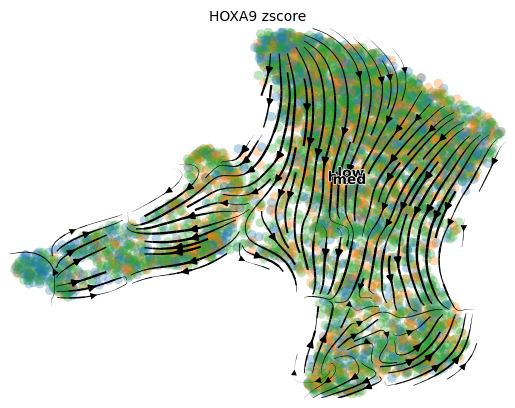

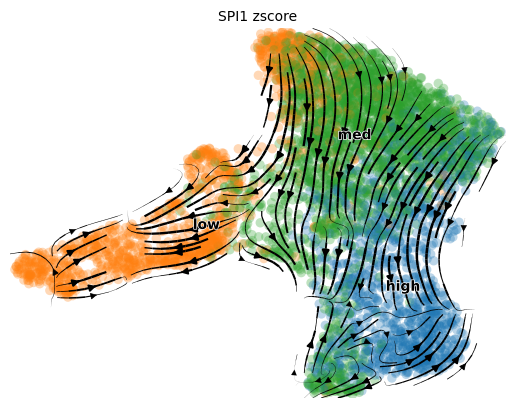

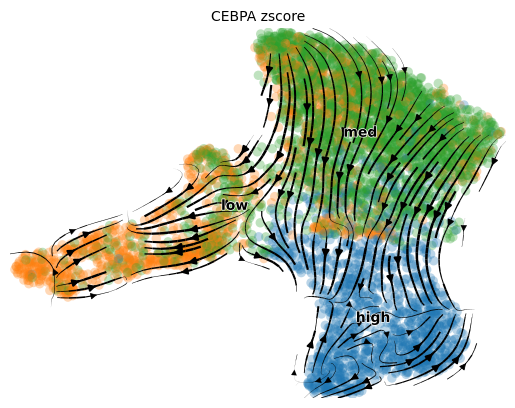

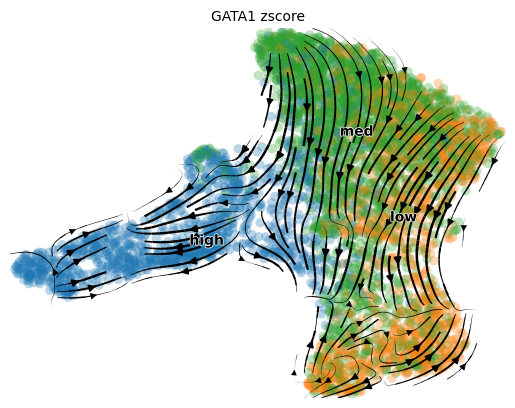

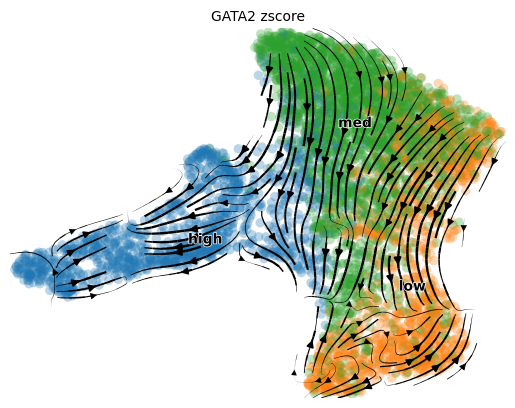

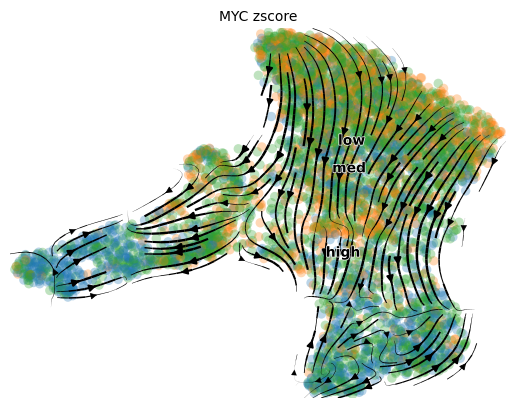

In [ ]:
for i, tf in enumerate(tfs): 
    mv.velocity_embedding_stream(
        mv_data, 
        basis='umap', 
        color=f"{tf}_zscore",
    )

In [19]:
for tf in tfs:
    zscore = mv_data.obs[f"{tf}_zscore"]
    celltype = mv_data.obs["celltype"]

    cond_non_mpp = celltype != "MPP"
    cond_med = zscore == "med"
    cond_high_mpp = (celltype == "MPP") & (zscore == "high")
    cond_low_mpp = (celltype == "MPP") & (zscore == "low")

    conditions = [cond_non_mpp, cond_med, cond_high_mpp, cond_low_mpp]
    choices = ["non-MPP", "med", "high_mpp", "low_mpp"]

    mv_data.obs[f"{tf}_zscore_mpp"] = np.select(
        conditions, choices, default="other"
    )

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/HOXA9_high_mpp.png


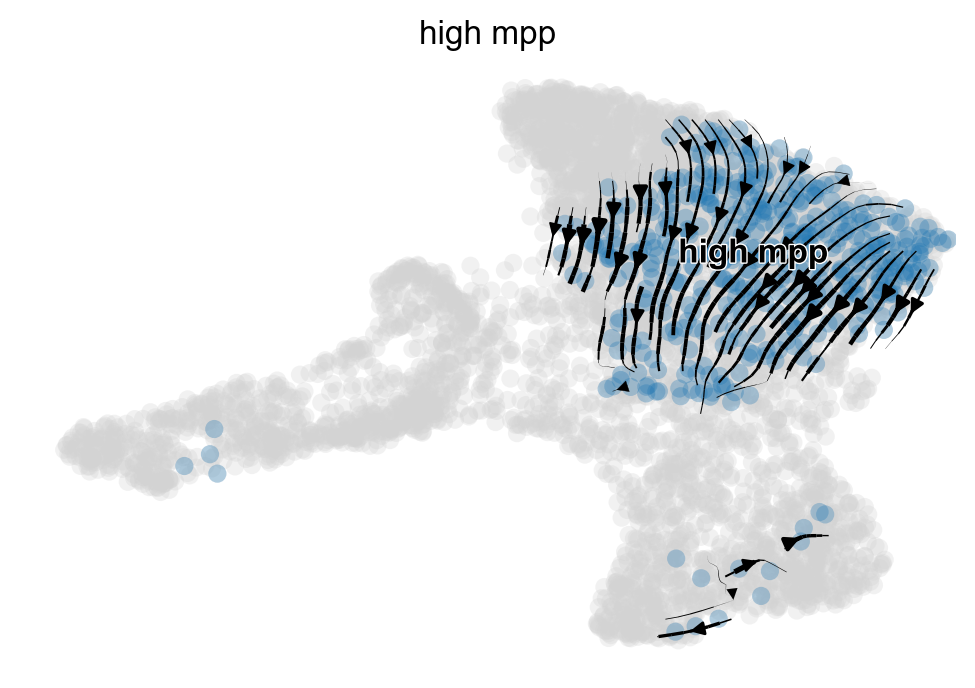

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/HOXA9_low_mpp.png


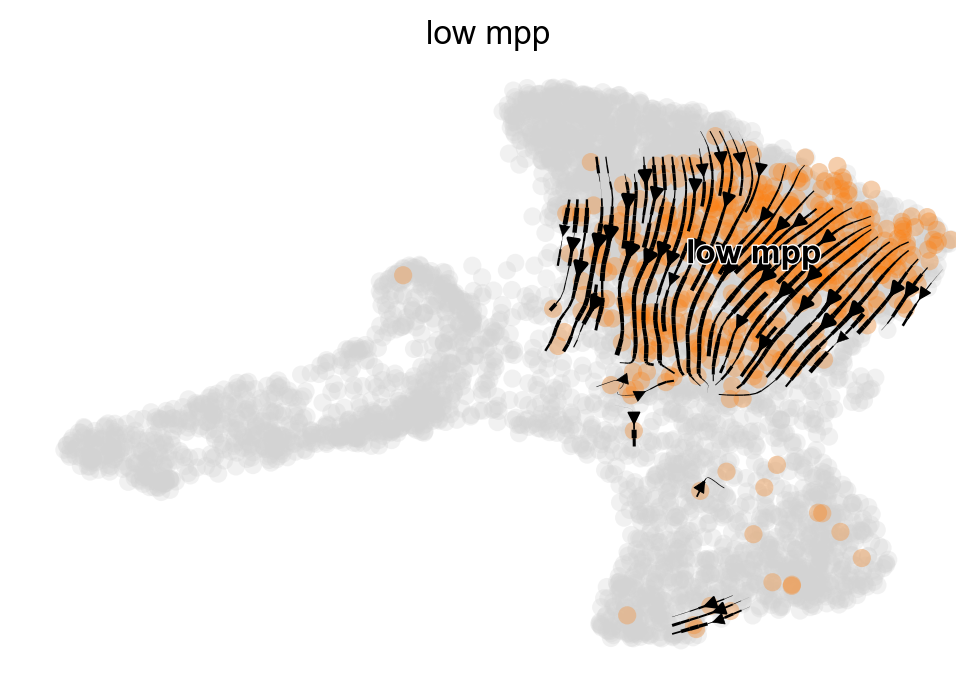

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/SPI1_high_mpp.png


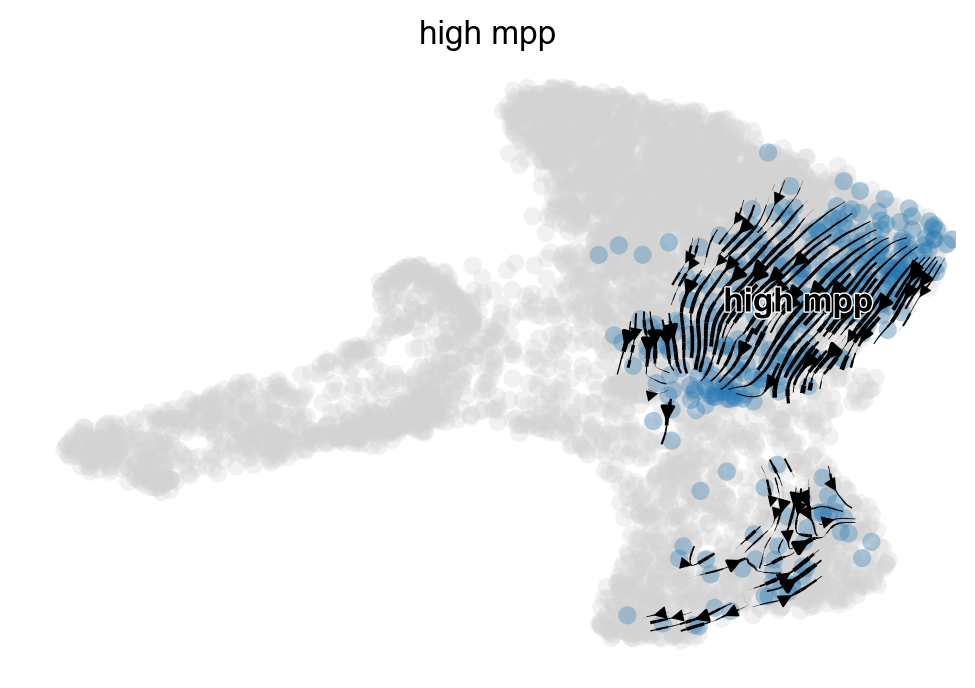

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/SPI1_low_mpp.png


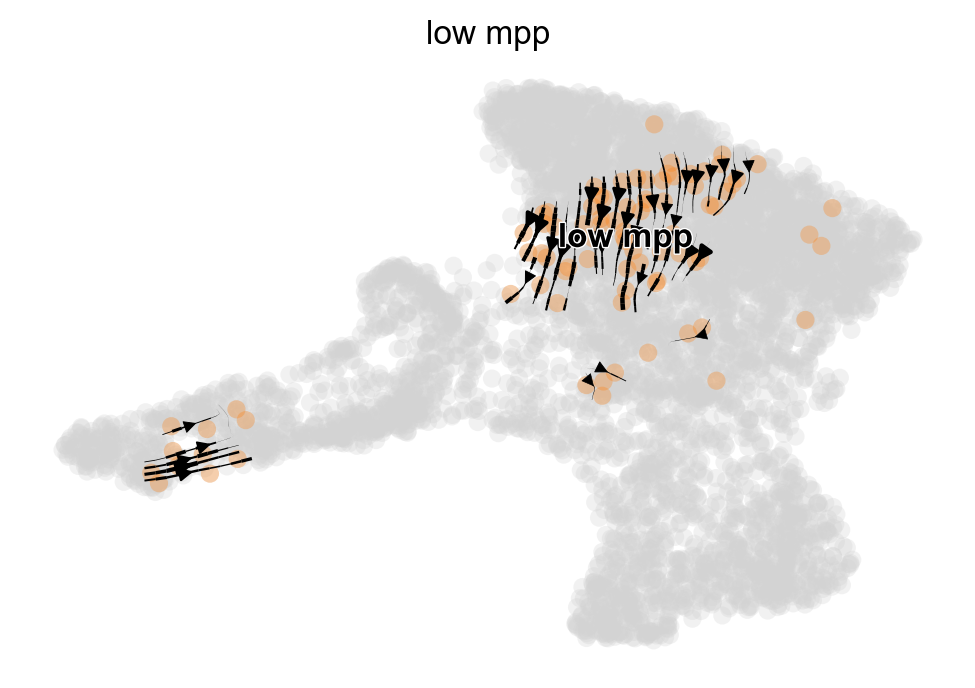

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/CEBPA_high_mpp.png


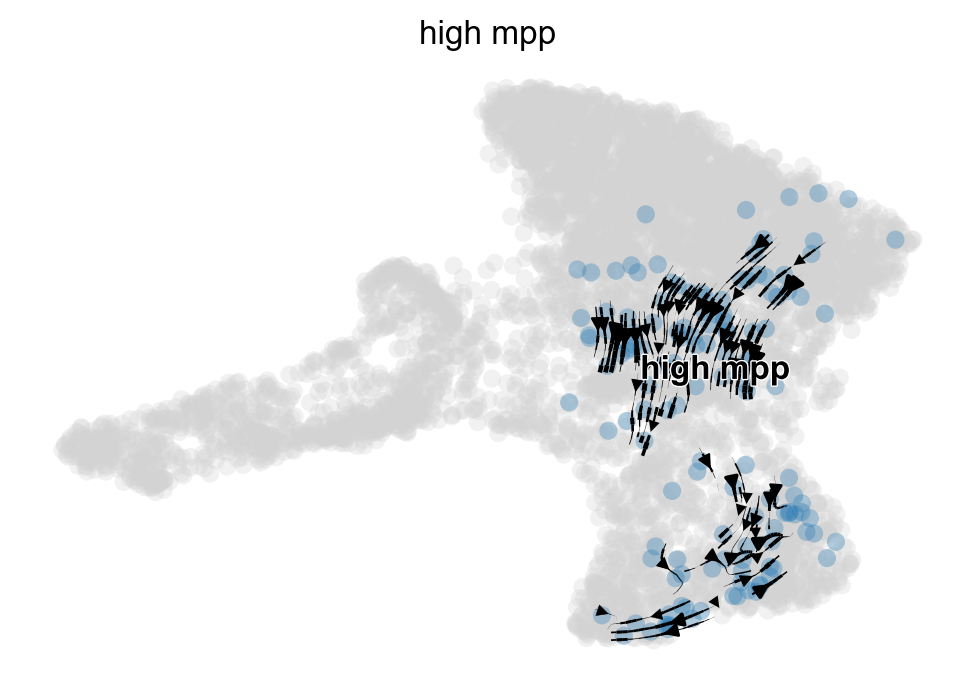

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/CEBPA_low_mpp.png


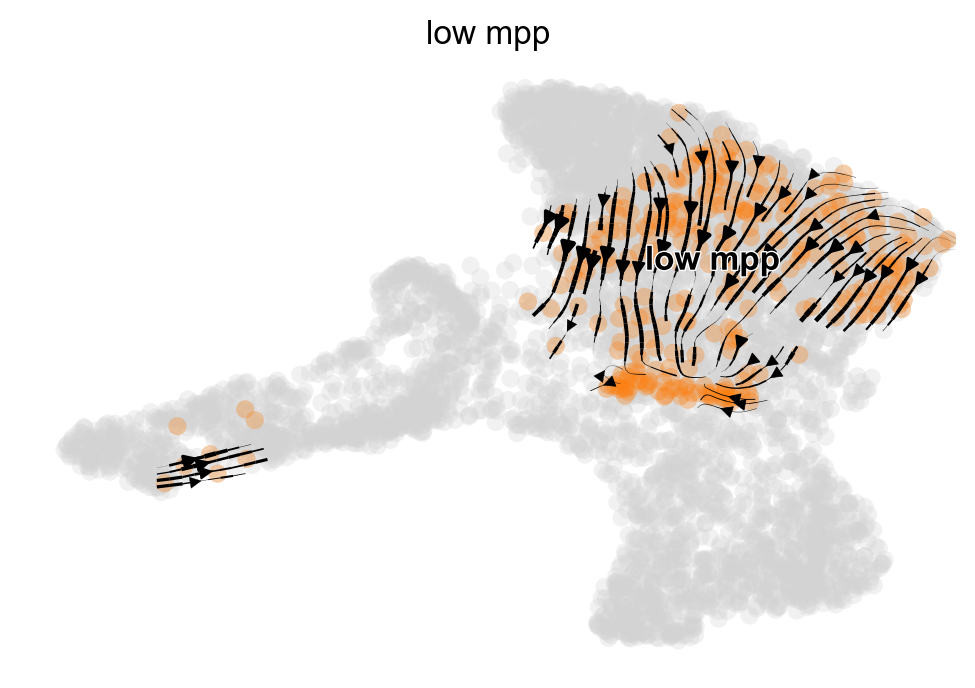

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA1_high_mpp.png


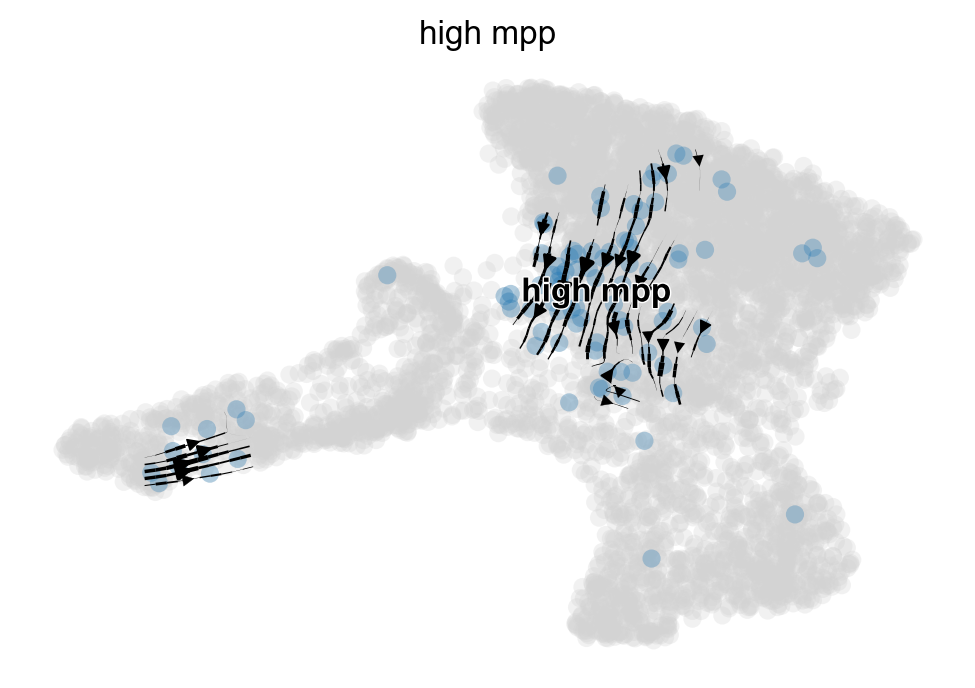

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA1_low_mpp.png


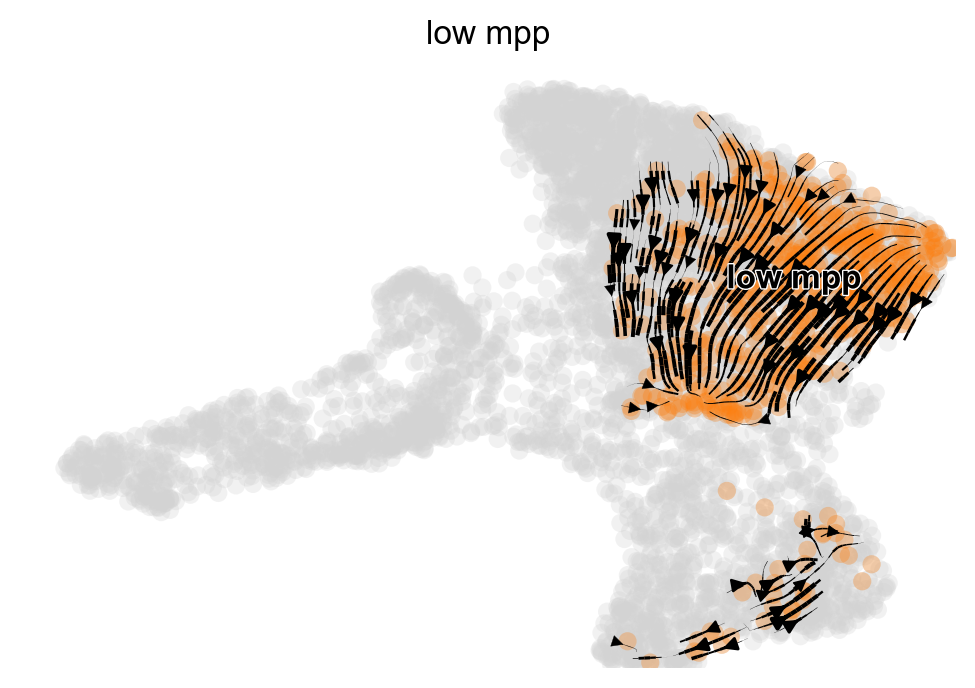

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA2_high_mpp.png


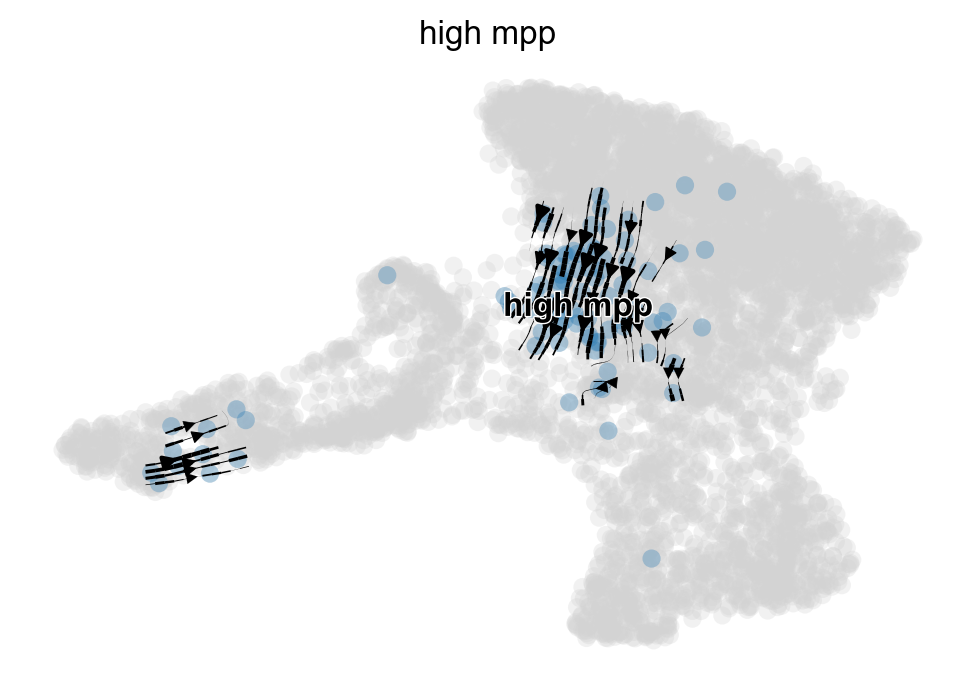

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA2_low_mpp.png


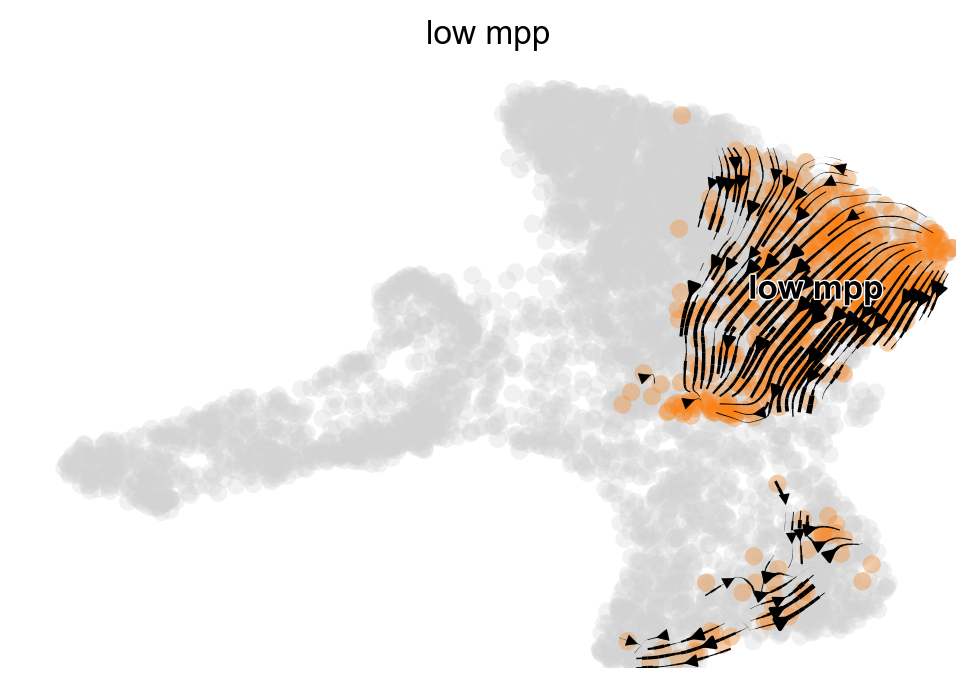

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/MYC_high_mpp.png


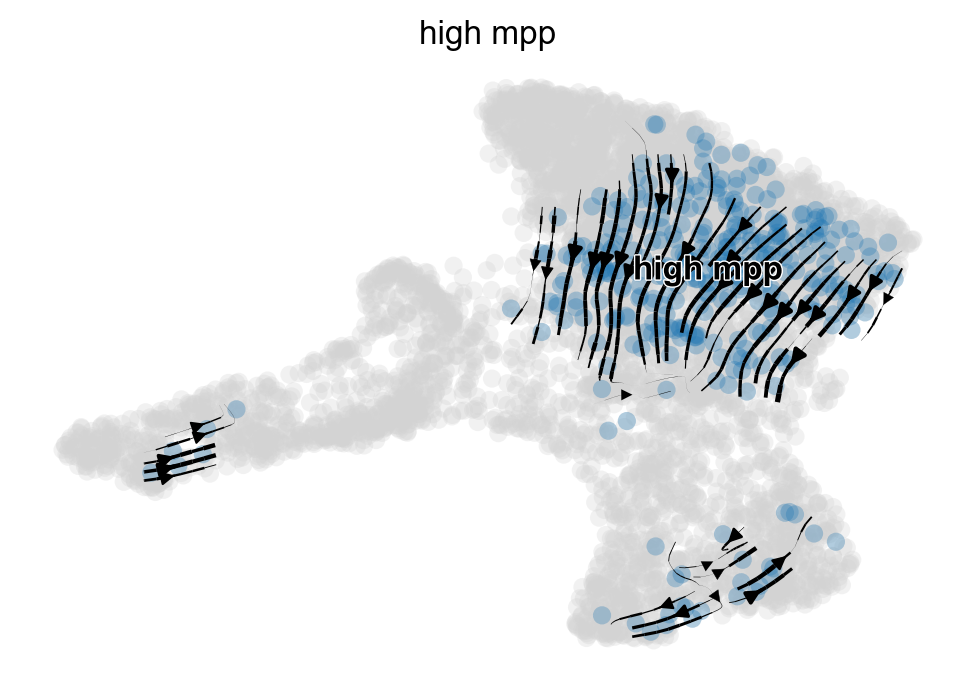

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/MYC_low_mpp.png


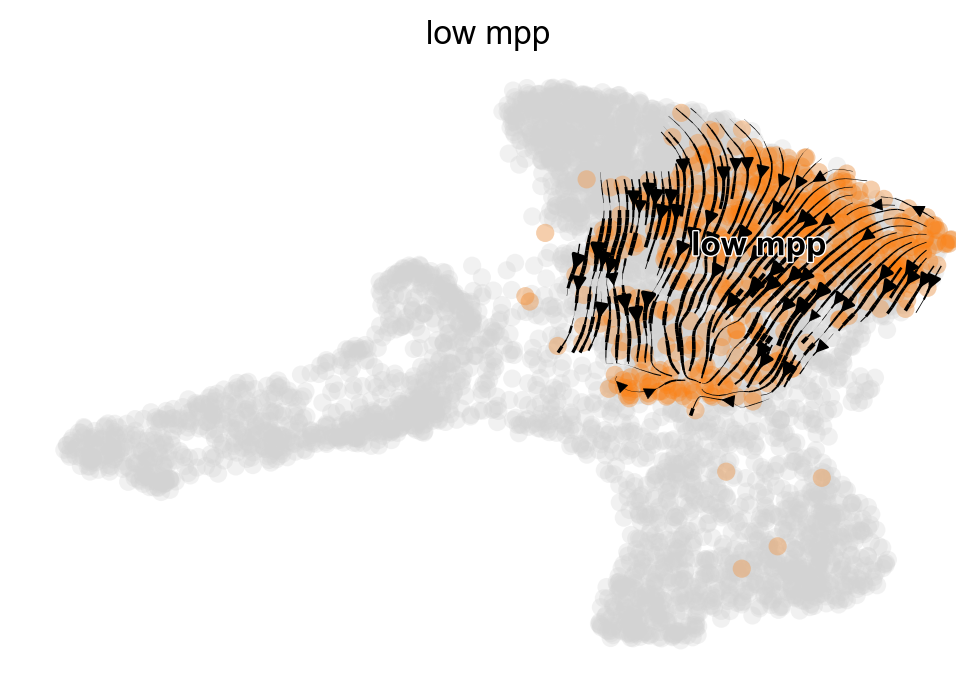

In [36]:
save_dir = Path(r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data\multivelo_comparison")

for tf in tfs:
    col = f"{tf}_zscore_mpp"

    save_path_high = (save_dir / f"{tf}_high_mpp.png").as_posix()
    save_path_low = (save_dir / f"{tf}_low_mpp.png").as_posix()

    mv.velocity_embedding_stream(mv_data, basis='umap', color=col, groups=["high_mpp"],
                                show=False, save=save_path_high)
    mv.velocity_embedding_stream(mv_data, basis='umap', color=col, groups=["low_mpp"],
                                show=False, save=save_path_low)


In [69]:
mv_data

AnnData object with n_obs × n_vars = 5241 × 940
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'SCT_snn_res.0.8', 'seurat_clusters', 'doublets_normal_cluster_based', 'doublets_random', 'doublets_RNA_consensus', 'nCount_SCT_no_regression', 'nFeature_SCT_no_regression', 'tricyclePosition', 'Phase_tricycle', 'tricycle_fine', 'cell_cycle_atac_classification', 'PromoterPercent', 'immunophenotype_predicted', 'predicted.id', 'prediction.score.LT', 'prediction.score.ST', 'prediction.score.MPP', 'prediction.score.LS_K', 'prediction.score.max', 'Identity_for_diff_testing', 'RF_prediction', 'angle_degree', 'immunophenotype_predicted_cleaned', 'HSC.promoters', 'LMPP.promoters', 'myeloid.promoters', 'MEP.promoters', 'HSC.TSS'

In [96]:
umap_velos = mv_data.obsm["velo_s_norm_umap"]
velo_df = pd.DataFrame(umap_velos, index=mv_data.obs_names.values)
velo_df.rename(columns={0:"vx", 1:"vy"}, inplace=True)
velo_df.index.rename("cell", inplace=True)
velo_df["celltype"] = mv_data.obs["celltype"]
velo_df[["x", "y"]] = mv_data.obsm["X_umap"]

for tf in tfs:
    velo_df[tf] = mv_data.obs[f"{tf}_zscore"]

In [99]:
mpp_subset = velo_df[velo_df["celltype"] == "MPP"]
non_mpp_subset = velo_df[velo_df["celltype"] != "MPP"]

for tf in tfs:

    hi_mask = (velo_df["celltype"] == "MPP") & (velo_df[tf] == "high")
    lo_mask = (velo_df["celltype"] == "MPP") & (velo_df[tf] == "low")

    X_avg_hi = np.mean(velo_df.loc[hi_mask, "x"])
    Y_avg_hi = np.mean(velo_df.loc[hi_mask, "y"])

    X_avg_lo = np.mean(velo_df.loc[lo_mask, "x"])
    Y_avg_lo = np.mean(velo_df.loc[lo_mask, "y"])

    vx_avg_hi = np.mean(velo_df.loc[hi_mask, "vx"])
    vy_avg_hi = np.mean(velo_df.loc[hi_mask, "vy"])

    vx_avg_lo = np.mean(velo_df.loc[lo_mask, "vx"])
    vy_avg_lo = np.mean(velo_df.loc[lo_mask, "vy"])

    plt.figure(figsize=(8, 8))

    plt.scatter(mpp_subset["x"], mpp_subset["y"], alpha=0.5, c="green", label="MPP")
    plt.scatter(non_mpp_subset["x"], non_mpp_subset["y"], alpha=0.5, c="lightgrey", label="non-MPP")

    plt.quiver(velo_df["x"], velo_df["y"], velo_df["vx"], velo_df["vy"], 
            angles='xy', scale_units='xy', scale=0.1, 
            color='gray', alpha=0.8, label='Individual Arrows')

    plt.quiver(X_avg_hi, Y_avg_hi, vx_avg_hi, vy_avg_hi, 
            angles='xy', scale_units='xy', scale=0.01, 
            color='red', width=0.01, label=f'{tf} High Avg')

    plt.quiver(X_avg_lo, Y_avg_lo, vx_avg_lo, vy_avg_lo, 
            angles='xy', scale_units='xy', scale=0.01, 
            color='blue', width=0.01, label=f'{tf} Low Avg')

    plt.legend()
    plt.title(f"Comparison of avg velocity by TF accessibility quantile")
    plt.savefig(rf"{python_data_dir}\multivelo_comparison\avg_velo\{tf}.png")
    plt.close()

In [105]:
hi_mask_hoxa9 = (velo_df["celltype"] == "MPP") & (velo_df["HOXA9"] == "high")
lo_mask_hoxa9 = (velo_df["celltype"] == "MPP") & (velo_df["HOXA9"] == "low")

In [106]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

hi_set = velo_df.loc[hi_mask_hoxa9, ["x", "y"]]
lo_set = velo_df.loc[lo_mask_hoxa9, ["x", "y"]]

cost_matrix = cdist(hi_set, lo_set, metric='euclidean')

In [109]:
row_ind, col_ind = linear_sum_assignment(cost_matrix)

In [111]:
pairs_df = pd.DataFrame(
    {
        "partner_hi": hi_set.index[row_ind],
        "partner_lo": lo_set.index[col_ind],
    }
)

In [113]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [156]:
z_map = {name.lower().capitalize(): name for name in z_scores.var_names.values}

intersect_genes = [(z_map[gene], gene) for gene in adata_atac.var_names.values if gene in z_map]

In [150]:
intersect_genes

array(['Ar', 'Bach2', 'Clock', 'Elk3', 'Esr1', 'Ets1', 'Foxn3', 'Foxo1',
       'Gata2', 'Gfi1', 'Gfi1b', 'Hlf', 'Hoxa7', 'Hoxa9', 'Irf2', 'Irf8',
       'Klf10', 'Klf12', 'Klf6', 'Mecom', 'Mef2a', 'Mef2c', 'Meis1',
       'Mitf', 'Mycn', 'Nfat5', 'Nfatc1', 'Nfatc2', 'Nfe2', 'Nfia',
       'Nr1d2', 'Pbx1', 'Pbx3', 'Pou2f1', 'Pou2f2', 'Rel', 'Rfx3', 'Rora',
       'Runx2', 'Smad3', 'Sox6', 'Sp4', 'Srebf2', 'Stat1', 'Stat3',
       'Stat4', 'Tcf7l2', 'Tfap4', 'Zeb1'], dtype=object)

In [158]:
angle_data = {}

for gene_z, gene_atac in intersect_genes:

    gene_data = z_scores[:, gene_z].X.flatten()

    labels = pd.qcut(
        gene_data,
        q=[0, 0.25, 0.75, 1.0],  
        labels=["low", "med", "high"],
    )

    velo_df[gene_atac] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)
    
    hi_mask_gene = (velo_df["celltype"] == "MPP") & (velo_df[gene_atac] == "high")
    lo_mask_gene = (velo_df["celltype"] == "MPP") & (velo_df[gene_atac] == "low")


    hi_set = velo_df.loc[hi_mask_gene, ["x", "y"]]
    lo_set = velo_df.loc[lo_mask_gene, ["x", "y"]]

    cost_matrix = cdist(hi_set, lo_set, metric='euclidean')
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    pairs_df = pd.DataFrame(
        {
            "partner_hi": hi_set.index[row_ind],
            "partner_lo": lo_set.index[col_ind],
        }
    )

    angle_data[gene_atac] = 0

    for i, row in pairs_df.iterrows():
        angle = angle_between(np.array([velo_df.loc[row["partner_hi"], "vx"], velo_df.loc[row["partner_hi"], "vy"]]),
                              np.array([velo_df.loc[row["partner_lo"], "vx"], velo_df.loc[row["partner_lo"], "vy"]]))

        angle_data[gene_atac] += angle
    velo_df.drop(columns=gene_atac, inplace=True)

angle_data


{'Ar': 111.13653517388681,
 'Bach2': 243.2239256085506,
 'Clock': 113.000929809041,
 'Elk3': 234.47935806510813,
 'Esr1': 112.06221881271495,
 'Ets1': 105.75856363010188,
 'Foxn3': 125.02985251165238,
 'Foxo1': 147.71873308544446,
 'Gata2': 72.00383714309979,
 'Gfi1': 60.056096053616926,
 'Gfi1b': 57.53777758960389,
 'Hlf': 151.41271430801228,
 'Hoxa7': 118.93821980229771,
 'Hoxa9': 122.77306845119693,
 'Irf2': 56.03997539150123,
 'Irf8': 65.07072103655686,
 'Klf10': 137.18237112943768,
 'Klf12': 85.83360625418295,
 'Klf6': 110.78065632599841,
 'Mecom': 61.24065567701185,
 'Mef2a': 82.24267241050443,
 'Mef2c': 81.41334402633123,
 'Meis1': 173.61145574162921,
 'Mitf': 123.48163416983797,
 'Mycn': 98.47157425924775,
 'Nfat5': 161.06573072944067,
 'Nfatc1': 183.55820268120146,
 'Nfatc2': 138.91601279619843,
 'Nfe2': 205.11346222535295,
 'Nfia': 160.29032261057083,
 'Nr1d2': 121.51212288555078,
 'Pbx1': 119.60373895623185,
 'Pbx3': 145.839290250962,
 'Pou2f1': 126.63790397852854,
 'Pou2f2'

In [167]:
angle_df = pd.DataFrame(angle_data.values(), index = angle_data.keys())

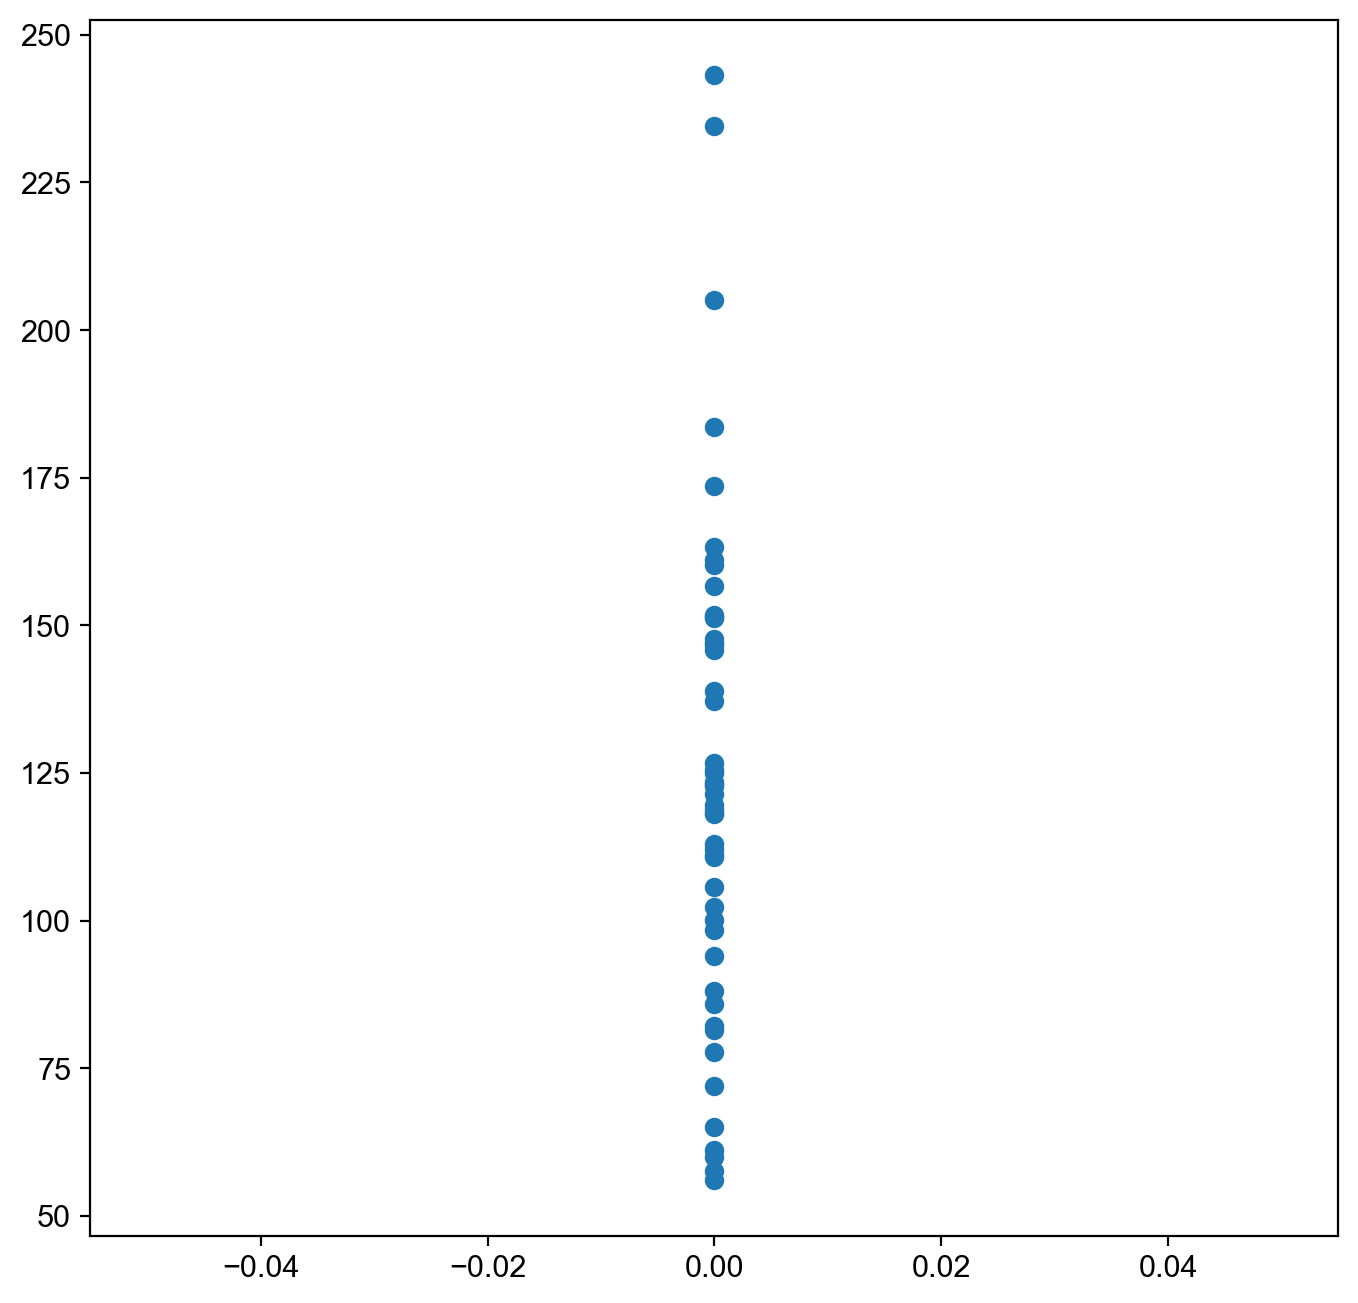

In [174]:
plt.figure(figsize=(8,8))
plt.scatter(x=np.zeros(len(angle_df)), y=angle_df.values)
plt.show()